In [1]:
import os
import pandas as pd
import networkx as nx
import community as community_louvain
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

os.chdir("/Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-network-analysis")

print("Working directory:", os.getcwd())

Working directory: /Users/cansezgin/Library/Mobile Documents/com~apple~CloudDocs/Claude_Projects/Computational Social Sciences/conflict-network-analysis


In [2]:
from itertools import product

ged = pd.read_csv("data/GEDEvent_v25_1.csv", low_memory=False)
ged['date_start'] = pd.to_datetime(ged['date_start'])

ethiopia = ged[
    (ged['country'] == 'Ethiopia') &
    (ged['date_start'] >= '2020-11-01') &
    (ged['date_start'] <= '2022-11-30')
].copy()

# Remove one-sided violence against civilians
battle_events = ethiopia[ethiopia['side_b'] != 'Civilians'].copy()

# Actor splitting function from Notebook 01
def split_actors(actor_string):
    if pd.isna(actor_string):
        return []
    parts = [a.strip() for a in actor_string.split(',')]
    merged = []
    i = 0
    while i < len(parts):
        if parts[i].startswith('Government of'):
            merged.append(parts[i])
        elif i + 1 < len(parts) and parts[i + 1].startswith('Government of'):
            merged.append(parts[i])
        elif i == len(parts) - 1:
            merged.append(parts[i])
        else:
            merged.append(parts[i])
        i += 1
    return merged

# Assign conflict phases
def assign_phase(date):
    if date <= pd.Timestamp('2021-06-30'):
        return 'Phase 1: War Outbreak\n(Nov 2020 - Jun 2021)'
    elif date <= pd.Timestamp('2021-12-31'):
        return 'Phase 2: TPLF Counteroffensive\n(Jul 2021 - Dec 2021)'
    elif date <= pd.Timestamp('2022-06-30'):
        return 'Phase 3: Re-escalation\n(Jan 2022 - Jun 2022)'
    else:
        return 'Phase 4: Ceasefire & Peace\n(Jul 2022 - Nov 2022)'

battle_events['phase'] = battle_events['date_start'].apply(assign_phase)

print("Events per phase:\n")
print(battle_events['phase'].value_counts().sort_index())

Events per phase:

phase
Phase 1: War Outbreak\n(Nov 2020 - Jun 2021)             242
Phase 2: TPLF Counteroffensive\n(Jul 2021 - Dec 2021)    277
Phase 3: Re-escalation\n(Jan 2022 - Jun 2022)            321
Phase 4: Ceasefire & Peace\n(Jul 2022 - Nov 2022)        370
Name: count, dtype: int64


In [3]:
# Define phase order for consistent plotting
phase_order = [
    'Phase 1: War Outbreak\n(Nov 2020 - Jun 2021)',
    'Phase 2: TPLF Counteroffensive\n(Jul 2021 - Dec 2021)',
    'Phase 3: Re-escalation\n(Jan 2022 - Jun 2022)',
    'Phase 4: Ceasefire & Peace\n(Jul 2022 - Nov 2022)'
]

# Build a network for each phase
phase_networks = {}

for phase in phase_order:
    phase_events = battle_events[battle_events['phase'] == phase]
    
    # Build edge list
    edges = []
    for _, row in phase_events.iterrows():
        actors_a = split_actors(row['side_a'])
        actors_b = split_actors(row['side_b'])
        for a, b in product(actors_a, actors_b):
            actor_pair = tuple(sorted([a, b]))
            edges.append({
                'actor_1': actor_pair[0],
                'actor_2': actor_pair[1],
                'fatalities': row['best']
            })
    
    edge_df = pd.DataFrame(edges)
    
    # Aggregate
    edge_weights = edge_df.groupby(['actor_1', 'actor_2']).agg(
        weight=('fatalities', 'size'),
        total_fatalities=('fatalities', 'sum')
    ).reset_index()
    
    # Build graph
    G_phase = nx.Graph()
    for _, row in edge_weights.iterrows():
        G_phase.add_edge(
            row['actor_1'], row['actor_2'],
            weight=row['weight'],
            fatalities=row['total_fatalities']
        )
    
    phase_networks[phase] = G_phase

# Print summary for each phase
print(f"{'Phase':<55} {'Nodes':>6} {'Edges':>6} {'Density':>8} {'Events':>7}")
print("-" * 85)

for phase in phase_order:
    G_p = phase_networks[phase]
    n_events = len(battle_events[battle_events['phase'] == phase])
    density = nx.density(G_p) if G_p.number_of_nodes() > 1 else 0
    print(f"{phase.replace(chr(10), ' '):<55} {G_p.number_of_nodes():>6} {G_p.number_of_edges():>6} {density:>8.3f} {n_events:>7}")

Phase                                                    Nodes  Edges  Density  Events
-------------------------------------------------------------------------------------
Phase 1: War Outbreak (Nov 2020 - Jun 2021)                  8      7    0.250     242
Phase 2: TPLF Counteroffensive (Jul 2021 - Dec 2021)         8      5    0.179     277
Phase 3: Re-escalation (Jan 2022 - Jun 2022)                 8      5    0.179     321
Phase 4: Ceasefire & Peace (Jul 2022 - Nov 2022)             5      3    0.300     370


In [5]:
print("Active actors per phase:\n")

for phase in phase_order:
    G_p = phase_networks[phase]
    actors = sorted(G_p.nodes())
    short_phase = phase.replace('\n', ' ')
    print(f"{short_phase}")
    for actor in actors:
        s = dict(G_p.degree(weight='weight'))
        print(f"    {actor:<30} interactions: {s[actor]}")
    print()

Active actors per phase:

Phase 1: War Outbreak (Nov 2020 - Jun 2021)
    Agaw                           interactions: 1
    Amhara                         interactions: 4
    Government of Ethiopia         interactions: 238
    Gumuz                          interactions: 7
    OLA                            interactions: 42
    Oromo                          interactions: 2
    Shinasha                       interactions: 2
    TPLF                           interactions: 196

Phase 2: TPLF Counteroffensive (Jul 2021 - Dec 2021)
    Al-Shabaab                     interactions: 1
    Amhara                         interactions: 1
    GLF                            interactions: 2
    Government of Ethiopia         interactions: 275
    Government of Somalia          interactions: 1
    OLA                            interactions: 112
    Oromo                          interactions: 1
    TPLF                           interactions: 161

Phase 3: Re-escalation (Jan 2022 - Jun 2022)
   

In [6]:
for phase in phase_order[2:]:
    G_p = phase_networks[phase]
    s = dict(G_p.degree(weight='weight'))
    short_phase = phase.replace('\n', ' ')
    print(f"{short_phase}")
    for actor in sorted(G_p.nodes()):
        print(f"    {actor:<30} interactions: {s[actor]}")
    print()

Phase 3: Re-escalation (Jan 2022 - Jun 2022)
    Burji                          interactions: 1
    GLF                            interactions: 1
    Government of Ethiopia         interactions: 319
    Guji                           interactions: 1
    Murle                          interactions: 1
    Nuer                           interactions: 1
    OLA                            interactions: 196
    TPLF                           interactions: 122

Phase 4: Ceasefire & Peace (Jul 2022 - Nov 2022)
    Al-Shabaab                     interactions: 5
    Government of Ethiopia         interactions: 365
    Government of Somalia          interactions: 5
    OLA                            interactions: 145
    TPLF                           interactions: 220



In [7]:
# Track degree centrality and strength for key actors across phases
key_actors = ['Government of Ethiopia', 'TPLF', 'OLA']

# Build tracking data
tracking_data = []

for phase in phase_order:
    G_p = phase_networks[phase]
    deg_cent = nx.degree_centrality(G_p)
    strength = dict(G_p.degree(weight='weight'))
    
    for actor in key_actors:
        if actor in G_p.nodes():
            tracking_data.append({
                'phase': phase.replace('\n', ' '),
                'phase_num': phase_order.index(phase) + 1,
                'actor': actor,
                'degree': G_p.degree(actor),
                'strength': strength[actor],
                'degree_centrality': deg_cent[actor]
            })
        else:
            tracking_data.append({
                'phase': phase.replace('\n', ' '),
                'phase_num': phase_order.index(phase) + 1,
                'actor': actor,
                'degree': 0,
                'strength': 0,
                'degree_centrality': 0
            })

track_df = pd.DataFrame(tracking_data)

print("Key actor metrics across phases:\n")
for actor in key_actors:
    print(f"{actor}")
    actor_data = track_df[track_df['actor'] == actor]
    for _, row in actor_data.iterrows():
        print(f"  Phase {row['phase_num']}: degree={row['degree']}, "
              f"interactions={row['strength']}, "
              f"degree_cent={row['degree_centrality']:.3f}")
    print()

Key actor metrics across phases:

Government of Ethiopia
  Phase 1: degree=2, interactions=238, degree_cent=0.286
  Phase 2: degree=3, interactions=275, degree_cent=0.429
  Phase 3: degree=3, interactions=319, degree_cent=0.429
  Phase 4: degree=2, interactions=365, degree_cent=0.500

TPLF
  Phase 1: degree=1, interactions=196, degree_cent=0.143
  Phase 2: degree=1, interactions=161, degree_cent=0.143
  Phase 3: degree=1, interactions=122, degree_cent=0.143
  Phase 4: degree=1, interactions=220, degree_cent=0.250

OLA
  Phase 1: degree=1, interactions=42, degree_cent=0.143
  Phase 2: degree=1, interactions=112, degree_cent=0.143
  Phase 3: degree=1, interactions=196, degree_cent=0.143
  Phase 4: degree=1, interactions=145, degree_cent=0.250



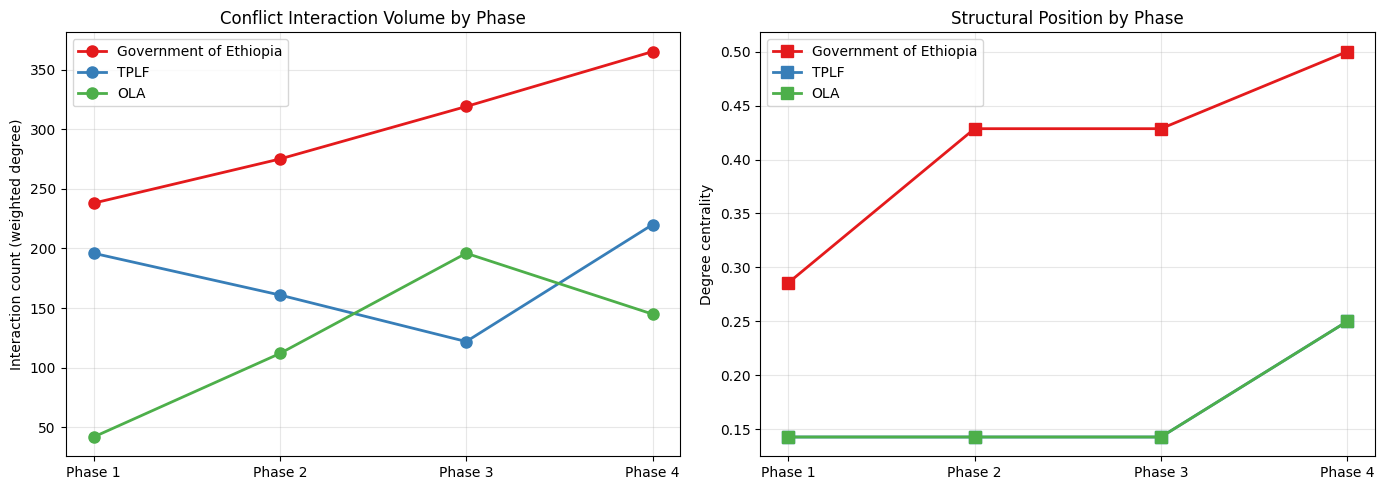

Saved to outputs/02_actor_trajectories.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

actor_colors = {
    'Government of Ethiopia': '#e41a1c',
    'TPLF': '#377eb8',
    'OLA': '#4daf4a'
}

phase_labels = ['Phase 1', 'Phase 2', 'Phase 3', 'Phase 4']

# Plot 1: Interaction volume over time
ax1 = axes[0]
for actor in key_actors:
    actor_data = track_df[track_df['actor'] == actor].sort_values('phase_num')
    ax1.plot(actor_data['phase_num'], actor_data['strength'],
             marker='o', linewidth=2, markersize=8,
             color=actor_colors[actor], label=actor)

ax1.set_xticks([1, 2, 3, 4])
ax1.set_xticklabels(phase_labels)
ax1.set_ylabel('Interaction count (weighted degree)')
ax1.set_title('Conflict Interaction Volume by Phase')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Degree centrality over time
ax2 = axes[1]
for actor in key_actors:
    actor_data = track_df[track_df['actor'] == actor].sort_values('phase_num')
    ax2.plot(actor_data['phase_num'], actor_data['degree_centrality'],
             marker='s', linewidth=2, markersize=8,
             color=actor_colors[actor], label=actor)

ax2.set_xticks([1, 2, 3, 4])
ax2.set_xticklabels(phase_labels)
ax2.set_ylabel('Degree centrality')
ax2.set_title('Structural Position by Phase')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/02_actor_trajectories.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to outputs/02_actor_trajectories.png")

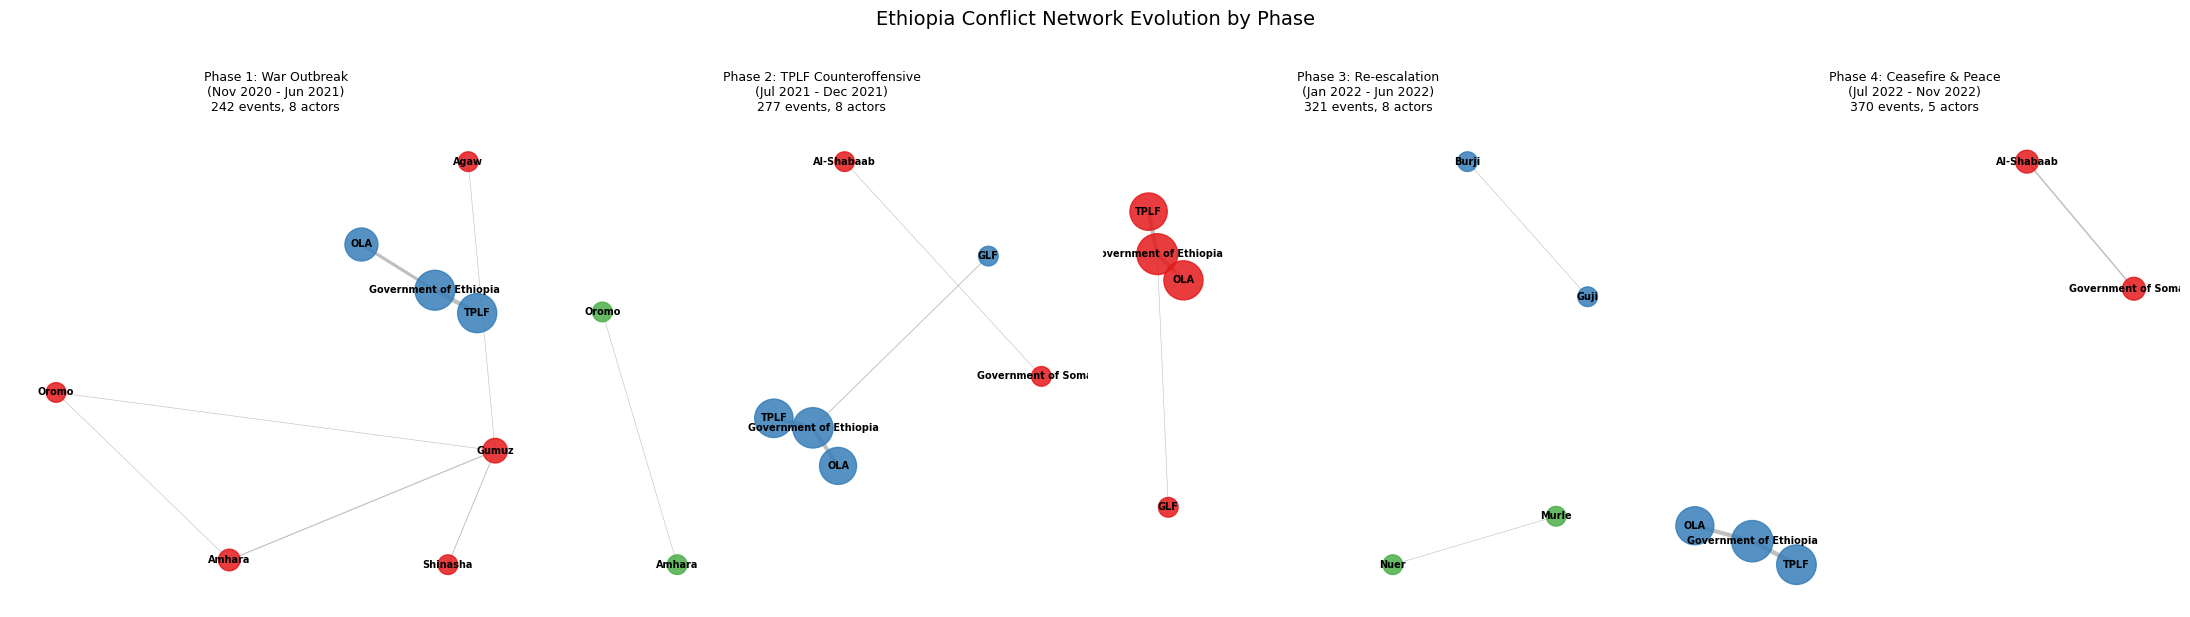

Saved to outputs/02_phase_networks.png


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

community_colors_map = {0: '#e41a1c', 1: '#377eb8', 2: '#4daf4a', 3: '#984ea3', 4: '#ff7f00'}

for idx, phase in enumerate(phase_order):
    ax = axes[idx]
    G_p = phase_networks[phase]
    
    # Community detection
    if G_p.number_of_nodes() > 1:
        partition_p = community_louvain.best_partition(G_p)
    else:
        partition_p = {n: 0 for n in G_p.nodes()}
    
    # Node colors by community
    node_colors = [community_colors_map[partition_p[n] % 5] for n in G_p.nodes()]
    
    # Node sizes by strength
    strength_p = dict(G_p.degree(weight='weight'))
    node_sizes = [max(200, np.log1p(strength_p[n]) * 150) for n in G_p.nodes()]
    
    # Edge widths
    edge_widths = [max(0.3, np.log1p(G_p[u][v]['weight']) * 0.6) for u, v in G_p.edges()]
    
    # Layout
    pos = nx.spring_layout(G_p, k=2.0, seed=42)
    
    nx.draw_networkx_edges(G_p, pos, ax=ax, width=edge_widths, alpha=0.5, edge_color='gray')
    nx.draw_networkx_nodes(G_p, pos, ax=ax, node_size=node_sizes, node_color=node_colors, alpha=0.85)
    nx.draw_networkx_labels(G_p, pos, ax=ax, font_size=7, font_weight='bold')
    
    # Phase title with event count
    n_events = len(battle_events[battle_events['phase'] == phase])
    short_title = phase.split('\n')[0]
    date_range = phase.split('\n')[1] if '\n' in phase else ''
    ax.set_title(f"{short_title}\n{date_range}\n{n_events} events, {G_p.number_of_nodes()} actors", fontsize=9)
    ax.axis('off')

plt.suptitle('Ethiopia Conflict Network Evolution by Phase', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('outputs/02_phase_networks.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to outputs/02_phase_networks.png")

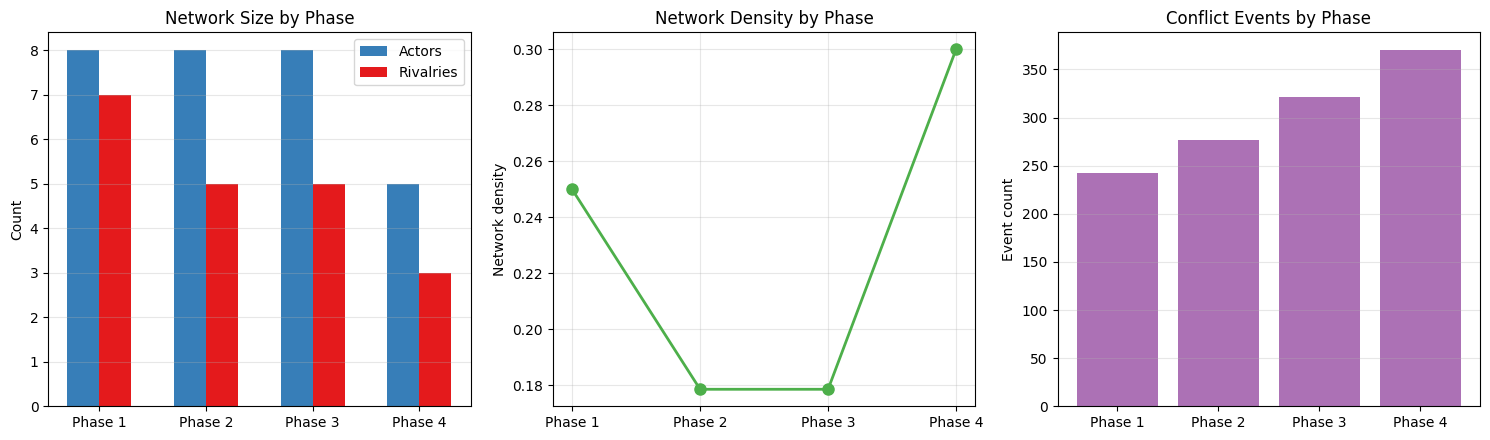

Saved to outputs/02_network_metrics.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

phases_short = ['Phase 1', 'Phase 2', 'Phase 3', 'Phase 4']

# Collect metrics
n_nodes = [phase_networks[p].number_of_nodes() for p in phase_order]
n_edges = [phase_networks[p].number_of_edges() for p in phase_order]
densities = [nx.density(phase_networks[p]) for p in phase_order]
event_counts = [len(battle_events[battle_events['phase'] == p]) for p in phase_order]

# Plot 1: Nodes and edges
ax1 = axes[0]
x = range(4)
ax1.bar([i - 0.15 for i in x], n_nodes, width=0.3, color='#377eb8', label='Actors')
ax1.bar([i + 0.15 for i in x], n_edges, width=0.3, color='#e41a1c', label='Rivalries')
ax1.set_xticks(x)
ax1.set_xticklabels(phases_short)
ax1.set_ylabel('Count')
ax1.set_title('Network Size by Phase')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Density
ax2 = axes[1]
ax2.plot(phases_short, densities, marker='o', linewidth=2, color='#4daf4a', markersize=8)
ax2.set_ylabel('Network density')
ax2.set_title('Network Density by Phase')
ax2.grid(True, alpha=0.3)

# Plot 3: Events per phase
ax3 = axes[2]
ax3.bar(phases_short, event_counts, color='#984ea3', alpha=0.8)
ax3.set_ylabel('Event count')
ax3.set_title('Conflict Events by Phase')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/02_network_metrics.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved to outputs/02_network_metrics.png")

In [11]:
print("=" * 65)
print("NOTEBOOK 02 SUMMARY: Temporal Network Evolution")
print("=" * 65)

print(f"""
CONFLICT PHASES
  Phase 1: War Outbreak (Nov 2020 - Jun 2021)      242 events
  Phase 2: TPLF Counteroffensive (Jul - Dec 2021)  277 events
  Phase 3: Re-escalation (Jan - Jun 2022)           321 events
  Phase 4: Ceasefire & Peace (Jul - Nov 2022)       370 events

NETWORK EVOLUTION
  Active actors:  8 -> 8 -> 8 -> 5
  Active edges:   7 -> 5 -> 5 -> 3
  Density:        0.250 -> 0.179 -> 0.179 -> 0.300

ACTOR TRAJECTORIES
  Government of Ethiopia: steady rise in both interaction volume
    (238 -> 275 -> 319 -> 365) and degree centrality
    (0.286 -> 0.429 -> 0.429 -> 0.500). The only actor fighting
    on multiple fronts in every phase.

  TPLF: interaction volume dipped during Phases 2-3 then surged
    to 220 in Phase 4 (final battles before the ceasefire).
    Degree stayed at 1 throughout, fighting only the government.

  OLA: rose from 42 interactions in Phase 1 to 196 in Phase 3,
    then fell to 145 in Phase 4. Reflects the intensification of
    the Oromiya insurgency during mid-conflict.

KEY FINDINGS
  1. The conflict network consolidated over time. Peripheral
     actors (ethnic communal violence groups) exited after
     Phase 1, leaving a smaller, denser core.
  2. Event volume increased as the network shrank. Fewer actors
     fought more intensely.
  3. Government of Ethiopia became structurally dominant,
     occupying the center of a star-shaped network in Phase 4.
  4. TPLF and OLA followed opposite arcs: TPLF dipped then
     surged, OLA rose then fell.
  5. The Phase 4 pattern (maximum events, minimum actors) is
     consistent with the escalation-before-ceasefire dynamic
     common in civil wars.

OUTPUTS
  outputs/02_actor_trajectories.png
  outputs/02_phase_networks.png
  outputs/02_network_metrics.png
""")

NOTEBOOK 02 SUMMARY: Temporal Network Evolution

CONFLICT PHASES
  Phase 1: War Outbreak (Nov 2020 - Jun 2021)      242 events
  Phase 2: TPLF Counteroffensive (Jul - Dec 2021)  277 events
  Phase 3: Re-escalation (Jan - Jun 2022)           321 events
  Phase 4: Ceasefire & Peace (Jul - Nov 2022)       370 events

NETWORK EVOLUTION
  Active actors:  8 -> 8 -> 8 -> 5
  Active edges:   7 -> 5 -> 5 -> 3
  Density:        0.250 -> 0.179 -> 0.179 -> 0.300

ACTOR TRAJECTORIES
  Government of Ethiopia: steady rise in both interaction volume
    (238 -> 275 -> 319 -> 365) and degree centrality
    (0.286 -> 0.429 -> 0.429 -> 0.500). The only actor fighting
    on multiple fronts in every phase.

  TPLF: interaction volume dipped during Phases 2-3 then surged
    to 220 in Phase 4 (final battles before the ceasefire).
    Degree stayed at 1 throughout, fighting only the government.

  OLA: rose from 42 interactions in Phase 1 to 196 in Phase 3,
    then fell to 145 in Phase 4. Reflects the inte